In [1]:
import warnings
warnings.filterwarnings("ignore")

from fredapi import Fred
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from scipy import stats

In [22]:
fred = Fred(api_key='e7d91fd4ac05e8ae87fa956d551f861f')
series_id = 'GDPC1'
data = fred.get_series(series_id)

gdp = pd.DataFrame(data, columns=[series_id])
gdp.index = pd.to_datetime(gdp.index)
gdp = pd.Series(gdp[series_id].values, index=pd.PeriodIndex(gdp.index, freq="Q"), name=series_id)

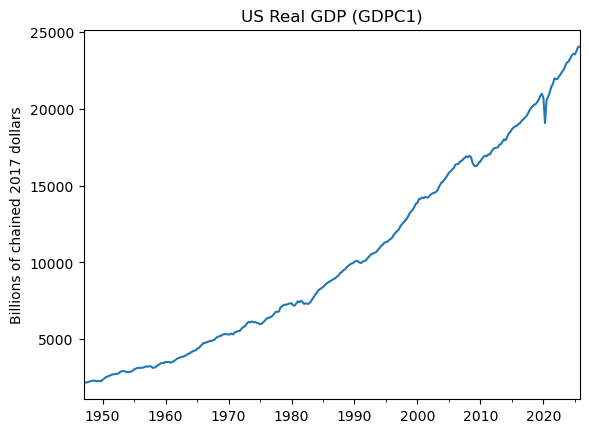

In [24]:
fig, ax = plt.subplots()
gdp.plot(ax=ax)
ax.set_title("US Real GDP (GDPC1)")
ax.set_ylabel("Billions of chained 2017 dollars")
plt.show()

## 1(a) Autocorrelation and partial autocorrelation for GDP

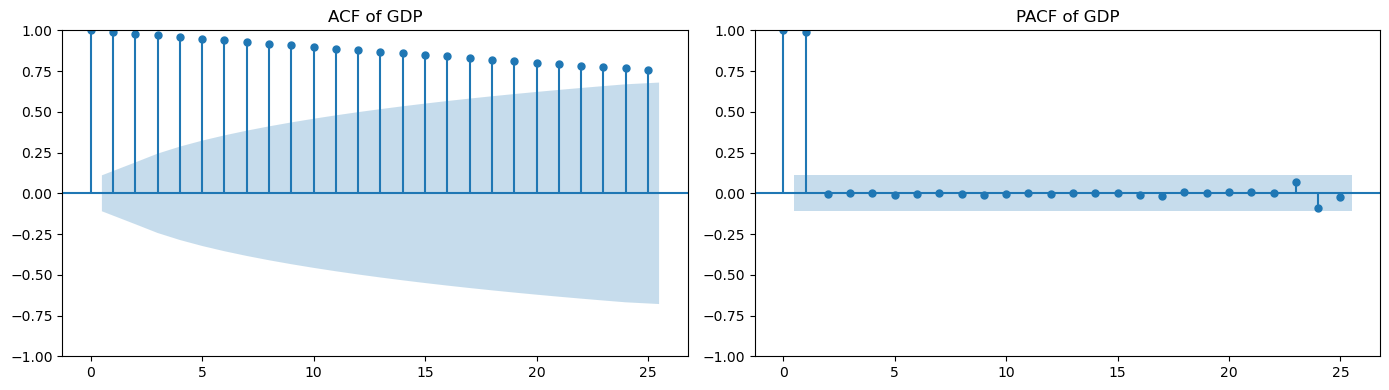

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(gdp, ax=axes[0])
plot_pacf(gdp, ax=axes[1])
axes[0].set_title("ACF of GDP")
axes[1].set_title("PACF of GDP")
plt.tight_layout()
plt.show()

## 1(b) Estimate a model suggested by the correlogram and compute 1- and 2-step-ahead forecasts
A common first pass is AR(1), but GDP often looks highly persistent, so you may also compare AR(2) or AR(4).

In [26]:
gdp_models = {}
for p in [1, 2, 4]:
    model = ARIMA(gdp, order=(p, 0, 0), trend="c").fit()
    fc = model.predict(start=len(gdp), end=len(gdp)+1, dynamic=False)
    gdp_models[p] = model

    print(model.summary())
    print("1-step and 2-step forecasts:")
    print(fc)

                               SARIMAX Results                                
Dep. Variable:                  GDPC1   No. Observations:                  316
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2066.762
Date:                Fri, 20 Mar 2026   AIC                           4139.523
Time:                        02:00:20   BIC                           4150.790
Sample:                    03-31-1947   HQIC                          4144.024
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.032e+04      0.706   1.46e+04      0.000    1.03e+04    1.03e+04
ar.L1          0.9999      0.000   2066.072      0.000       0.999       1.001
sigma2      2.735e+04    436.596     62.642      0.0

c:\Users\Jung Jae Kim\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 1(c) Estimate AR(1) for GDP and compute the root

In [28]:
gdp_ar1 = ARIMA(gdp, order=(1, 0, 0), trend="c").fit()
phi = gdp_ar1.params.iloc[1]

print(gdp_ar1.summary())
print(f"AR(1) coefficient phi = {phi:.6f}")

                               SARIMAX Results                                
Dep. Variable:                  GDPC1   No. Observations:                  316
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2066.762
Date:                Fri, 20 Mar 2026   AIC                           4139.523
Time:                        02:02:06   BIC                           4150.790
Sample:                    03-31-1947   HQIC                          4144.024
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.032e+04      0.706   1.46e+04      0.000    1.03e+04    1.03e+04
ar.L1          0.9999      0.000   2066.072      0.000       0.999       1.001
sigma2      2.735e+04    436.596     62.642      0.0

## 1(d) Unit root test for GDP
For a macro level series like GDP, it is usually sensible to test models **with a constant and possibly a deterministic trend**.

Below I run:
- ADF with constant only
- ADF with constant + trend

In [31]:
adf_gdp_c = adfuller(gdp.dropna(), maxlag=4, regression="c", autolag=None)
adf_gdp_ct = adfuller(gdp.dropna(), maxlag=4, regression="ct", autolag=None)

print("ADF test for GDP (constant)")
print(f"test statistic = {adf_gdp_c[0]:.4f}")
print(f"p-value        = {adf_gdp_c[1]:.4f}")
print(f"used lag       = {adf_gdp_c[2]}")
print(f"nobs           = {adf_gdp_c[3]}")
print("critical values:")
for k, v in adf_gdp_c[4].items():
    print(f"  {k}: {v:.4f}")

print()
print("ADF test for GDP (constant + trend)")
print(f"test statistic = {adf_gdp_ct[0]:.4f}")
print(f"p-value        = {adf_gdp_ct[1]:.4f}")
print(f"used lag       = {adf_gdp_ct[2]}")
print(f"nobs           = {adf_gdp_ct[3]}")
print("critical values:")
for k, v in adf_gdp_ct[4].items():
    print(f"  {k}: {v:.4f}")

ADF test for GDP (constant)
test statistic = 4.0945
p-value        = 1.0000
used lag       = 4
nobs           = 311
critical values:
  1%: -3.4516
  5%: -2.8709
  10%: -2.5717

ADF test for GDP (constant + trend)
test statistic = -0.3880
p-value        = 0.9872
used lag       = 4
nobs           = 311
critical values:
  1%: -3.9882
  5%: -3.4247
  10%: -3.1354


# 2) PCE inflation analysis

In [59]:
series_id = 'PCECTPI'
data = fred.get_series(series_id, observation_start='1963-01-01', observation_end='2019-12-31')

pce = pd.DataFrame(data, columns=[series_id])
pce.index = pd.to_datetime(pce.index)
pce = pd.Series(pce[series_id].values, index=pd.PeriodIndex(pce.index, freq="Q"), name=series_id)

In [60]:
infl = 400 * np.log(pce / pce.shift(1))
infl.name = "Infl"

infl_sample = infl.dropna()

print(infl_sample)


1963Q2    0.624356
1963Q3    1.941751
1963Q4    1.462524
1964Q1    1.900710
1964Q2    0.860982
            ...   
2018Q4    1.514917
2019Q1    0.813653
2019Q2    2.230017
2019Q3    0.961850
2019Q4    1.571061
Freq: Q-DEC, Name: Infl, Length: 227, dtype: float64


The series `Infl` is an **annualized inflation rate in percent per year**:
- `ln(P_t) - ln(P_{t-1})` is quarterly log inflation
- multiplying by 4 annualizes
- multiplying by 100 converts to percent
- together that gives the factor **400**

## 2(b) Plot inflation from 1963Q1 to 2019Q4

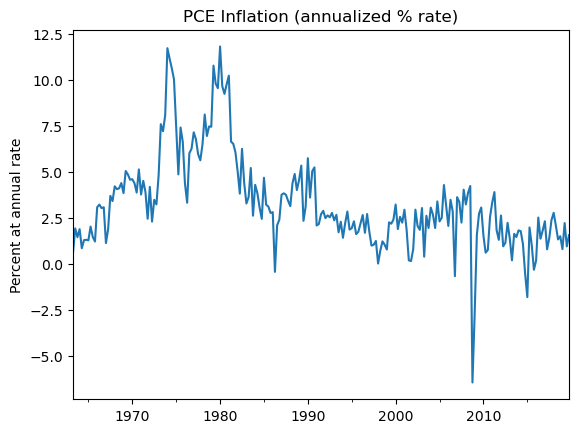

In [61]:
fig, ax = plt.subplots()
infl_sample.plot(ax=ax)
ax.set_title("PCE Inflation (annualized % rate)")
ax.set_ylabel("Percent at annual rate")
plt.show()

## 2(c) First four autocorrelations of ΔInfl

In [62]:
dinfl = infl.diff()
dinfl.name = "dInfl"
dinfl_sample = dinfl.dropna()

acf_vals = acf(dinfl_sample, nlags=4, fft=False)
acf_table = pd.DataFrame({
    "lag": range(1, 5),
    "acf_dInfl": acf_vals[1:5]
})
acf_table

,lag,acf_dInfl
0,1,-0.251685
1,2,-0.208214
2,3,0.129935
3,4,-0.077543


## 2(d) Plot ΔInfl

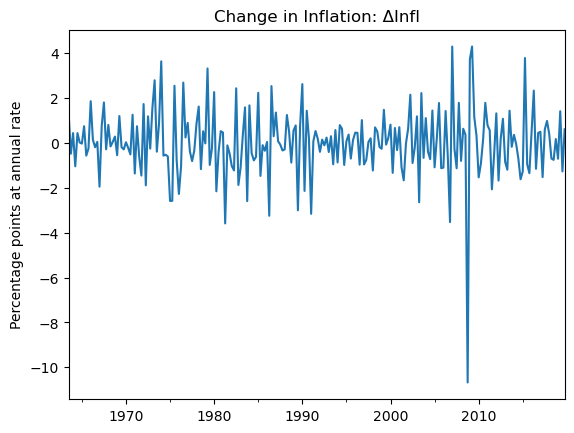

In [63]:
fig, ax = plt.subplots()
dinfl_sample.plot(ax=ax)
ax.set_title("Change in Inflation: ΔInfl")
ax.set_ylabel("Percentage points at annual rate")
plt.show()

## 2(e) OLS regression of ΔInfl_t on ΔInfl_(t-1)

In [64]:
df_e = pd.DataFrame({
    "dInfl": dinfl_sample,
    "dInfl_lag1": dinfl_sample.shift(1)
}).dropna()

reg_e = OLS(df_e["dInfl"], add_constant(df_e["dInfl_lag1"])).fit()
print(reg_e.summary())

                            OLS Regression Results                            
Dep. Variable:                  dInfl   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     15.15
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           0.000131
Time:                        02:25:45   Log-Likelihood:                -406.59
No. Observations:                 225   AIC:                             817.2
Df Residuals:                     223   BIC:                             824.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.099     -0.013      0.9

## 2(f) AR(2) model for ΔInfl and comparison with AR(1)

In [65]:
ar1_dinfl = ARIMA(dinfl_sample, order=(1, 0, 0), trend="c").fit()
ar2_dinfl = ARIMA(dinfl_sample, order=(2, 0, 0), trend="c").fit()

print(ar1_dinfl.summary())
print(ar2_dinfl.summary())

comparison = pd.DataFrame({
    "model": ["AR(1)", "AR(2)"],
    "AIC": [ar1_dinfl.aic, ar2_dinfl.aic],
    "BIC": [ar1_dinfl.bic, ar2_dinfl.bic],
})
comparison

                               SARIMAX Results                                
Dep. Variable:                  dInfl   No. Observations:                  226
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -408.308
Date:                Fri, 20 Mar 2026   AIC                            822.616
Time:                        02:25:45   BIC                            832.878
Sample:                    09-30-1963   HQIC                           826.757
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0025      0.085      0.029      0.977      -0.164       0.169
ar.L1         -0.2516      0.062     -4.049      0.000      -0.373      -0.130
sigma2         2.1710      0.085     25.529      0.0

,model,AIC,BIC
0,AR(1),822.616018,832.877623
1,AR(2),804.864303,818.546443


## 2(g) AR(p) for p = 0, ..., 8 and lag selection by AIC/BIC
For `p=0`, this is just a constant-only mean model.

In [66]:
rows = []

# p = 0
y0 = dinfl_sample.dropna()
X0 = np.ones((len(y0), 1))
m0 = OLS(y0, X0).fit()
rows.append({"p": 0, "AIC": m0.aic, "BIC": m0.bic})

for p in range(1, 9):
    mp = ARIMA(dinfl_sample, order=(p, 0, 0), trend="c").fit()
    rows.append({"p": p, "AIC": mp.aic, "BIC": mp.bic})

ic_table = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
display(ic_table)

best_aic_p = ic_table.loc[ic_table["AIC"].idxmin(), "p"]
best_bic_p = ic_table.loc[ic_table["BIC"].idxmin(), "p"]

print(f"Lag chosen by AIC: p = {best_aic_p}")
print(f"Lag chosen by BIC: p = {best_bic_p}")

,p,AIC,BIC
0,0,833.401671,836.822206
1,1,822.616018,832.877623
2,2,804.864303,818.546443
3,3,806.832271,823.934946
4,4,805.768883,826.292093
5,5,804.775849,828.719594
6,6,805.448646,832.812926
7,7,807.436884,838.221699
8,8,808.939655,843.145005


Lag chosen by AIC: p = 5
Lag chosen by BIC: p = 2


## 2(h) Use AR(2) to predict ΔInfl for 2020Q1
Estimate the AR(2) on data through **2019Q4**, then produce the one-step-ahead forecast for **2020Q1**.

In [67]:
ar2 = ARIMA(dinfl_sample, order=(2, 0, 0), trend="c").fit()

forecast_dinfl_2020q1 = ar2.predict(start=len(dinfl_sample), end=len(dinfl_sample), dynamic=False).iloc[0]
print(f"Forecast for ΔInfl_2020Q1 = {forecast_dinfl_2020q1:.4f}")


Forecast for ΔInfl_2020Q1 = 0.1727


## 2(i) Use the AR(2) model to predict the level of inflation in 2020Q1

In [68]:
ar2 = ARIMA(infl_sample, order=(2, 0, 0), trend="c").fit()

forecast_infl_2020q1 = ar2.predict(start=len(infl_sample), end=len(infl_sample), dynamic=False).iloc[0]
print(f"Forecast for Infl_2020Q1 = {forecast_infl_2020q1:.4f}")

Forecast for Infl_2020Q1 = 1.6967


## 2(j) ADF test with two lags, constant-only model, on ΔInfl
This tests for a stochastic trend in `Infl`.

In [69]:
adf_infl_2lags = adfuller(infl_sample.dropna(), maxlag=2, regression="c", autolag=None)

print("ADF test for Infl (constant only, 2 lags)")
print(f"test statistic = {adf_infl_2lags[0]:.4f}")
print(f"p-value        = {adf_infl_2lags[1]:.4f}")
print(f"used lag       = {adf_infl_2lags[2]}")
print(f"nobs           = {adf_infl_2lags[3]}")
print("critical values:")
for k, v in adf_infl_2lags[4].items():
    print(f"  {k}: {v:.4f}")

ADF test for Infl (constant only, 2 lags)
test statistic = -2.7930
p-value        = 0.0593
used lag       = 2
nobs           = 224
critical values:
  1%: -3.4599
  5%: -2.8745
  10%: -2.5737


## 2(m) Does the AR model for Infl contain a unit root?


In [72]:
ar1 = ARIMA(infl_sample, order=(1, 0, 0), trend="c").fit()
print(ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                   Infl   No. Observations:                  227
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -407.441
Date:                Fri, 20 Mar 2026   AIC                            820.882
Time:                        02:26:10   BIC                            831.157
Sample:                    06-30-1963   HQIC                           825.028
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2133      0.575      5.584      0.000       2.085       4.341
ar.L1          0.8219      0.034     24.508      0.000       0.756       0.888
sigma2         2.1106      0.082     25.767      0.0

## 2(o) Recursive pseudo out-of-sample forecasts for ΔInfl, from 2005Q1 to 2019Q4
At each forecast origin:
- estimate AR(2) using data available up to the previous quarter
- make a one-step-ahead forecast

In [73]:
s = pd.Series(dinfl_sample).dropna().copy()
start_forecast_period = pd.Period("2005Q1", freq="Q")
start_loc = s.index.get_loc(start_forecast_period)

forecast_dict = {}
actual_dict = {}

for i in range(start_loc, len(s)):
    train = s.iloc[:i]
    model = ARIMA(train, order=(2, 0, 0), trend="c").fit()
    pred = model.predict(start=len(train), end=len(train), dynamic=False).iloc[0]

    forecast_dict[s.index[i]] = pred
    actual_dict[s.index[i]] = s.iloc[i]

poos = pd.DataFrame({
    "actual": pd.Series(actual_dict),
    "forecast": pd.Series(forecast_dict)
})
poos["error"] = poos["actual"] - poos["forecast"]

poos.head(), poos.tail()

(          actual  forecast     error
 2005Q1 -1.087280 -0.325030 -0.762250
 2005Q2  0.197346  0.108774  0.088572
 2005Q3  1.781547  0.149773  1.631773
 2005Q4 -1.126099 -0.611723 -0.514376
 2006Q1 -1.099789  0.058154 -1.157944,
           actual  forecast     error
 2018Q4  0.174829  0.448868 -0.274038
 2019Q1 -0.701263  0.168444 -0.869707
 2019Q2  1.416364  0.172709  1.243655
 2019Q3 -1.268167 -0.244092 -1.024075
 2019Q4  0.609211 -0.000420  0.609630)

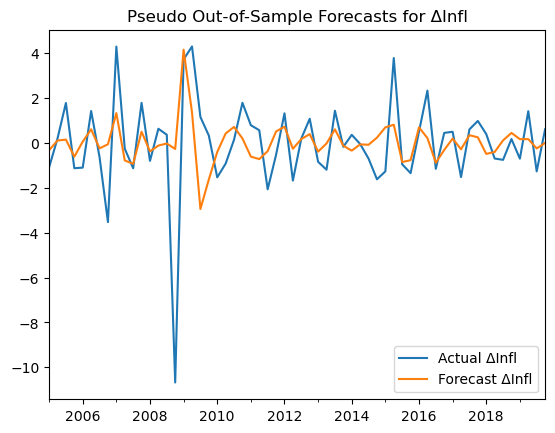

In [74]:
fig, ax = plt.subplots()
poos["actual"].plot(ax=ax, label="Actual ΔInfl")
poos["forecast"].plot(ax=ax, label="Forecast ΔInfl")
ax.set_title("Pseudo Out-of-Sample Forecasts for ΔInfl")
ax.legend()
plt.show()

## 2(p) Are the pseudo out-of-sample forecasts biased?
Test whether the forecast errors have mean zero.

In [78]:
errors = pd.Series(poos["error"]).dropna()
t_stat, p_val = stats.ttest_1samp(errors, popmean=0)
print(t_stat, p_val)

-0.1558674656165107 0.8766695705333474


## 2(q) RMSFE of the pseudo out-of-sample forecasts

In [79]:
poos_rmsfe = np.sqrt(np.mean(errors ** 2))
print(f"RMSFE = {poos_rmsfe:.4f}")

RMSFE = 1.8977


## 2(r) Large outlier in 2008Q4 and oil prices
The assignment asks why inflation fell so much in 2008Q4.  
The standard explanation is the collapse in oil prices during the 2008 financial crisis.

This code downloads WTI crude oil prices from FRED and plots 2007–2009.

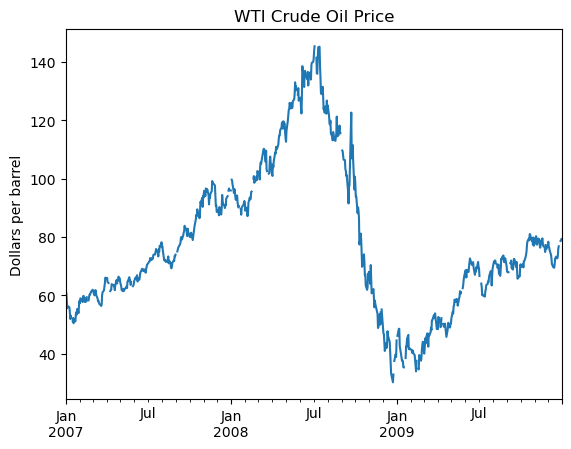

In [85]:
series_id = 'DCOILWTICO'
data = fred.get_series(series_id, observation_start='2007-01-01', observation_end='2009-12-31')

oil = pd.DataFrame(data, columns=[series_id])
oil.index = pd.to_datetime(oil.index)
oil = pd.Series(oil[series_id].values, index=pd.PeriodIndex(oil.index, freq="D"), name=series_id)

fig, ax = plt.subplots()
oil.plot(ax=ax)
ax.set_title("WTI Crude Oil Price")
ax.set_ylabel("Dollars per barrel")
plt.show()